# Notebook 3: Training

How the agent went from 0% to 99% checkmate.  
Each section documents one decision that actually moved the number.

In [591]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))
sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))

import torch
import numpy as np
import matplotlib.pyplot as plt
import json

from itertools import groupby as _gb
from agents.v6.ppo_agent import PPOAgent
AGENTS_DIR = os.path.join(os.path.dirname(os.path.abspath("__file__")), "agents")

## 1. The Training Loop

All agents share the same structure:

repeat:
   1. Run N episodes then collect (observation, action, reward) tuples
   2. Compute discounted returns
   3. Compute policy gradient loss, update weights

What changes between versions:
- How the gradient is estimated i.e., the algorithm (REINFORCE / A2C / PPO)
- What positions the agent trains on (curriculum ratio)
- What rewards it receives (reward shaping)
- Who it plays against (random / centrality / neural opponent)

## 2. Agent Progression

| Version  | Algorithm     | Key change                                                | Checkmate rate                     |
|----------|---------------|-----------------------------------------------------------|------------------------------------|
| v1       | REINFORCE     | Baseline                                                  | ~5%                                |
| v2       | REINFORCE     | + Curriculum (mate-in-1 pool)                             | ~15%                               |
| v3       | A2C           | + Critic baseline                                         | ~8%                                |
| v4       | REINFORCE     | + Reward shaping + centrality opponent + 3M eps           | ~88%                               |
| v5       | PPO           | + Clipped surrogate objective, 4 update epochs per batch  | ~99%                               |
| v6       | PPO           | + Self-play (neural opponent)                             | ~93% vs neural, ~99% vs centrality |

**Why is A2C (v3) worse than REINFORCE (v2)?**  
A2C subtracts a value baseline to reduce variance: `advantage = G_t − V(s_t)`. That only helps if the value estimate is accurate. Early in training the critic is noisy, so the baseline adds variance instead of removing it. REINFORCE with normalized returns is simpler and more stable at this scale.

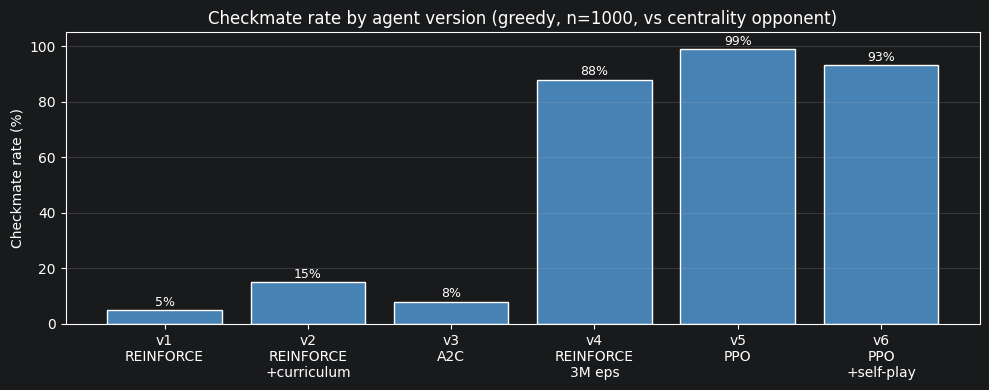

In [592]:
versions = ["v1\nREINFORCE", "v2\nREINFORCE\n+curriculum",
           "v3\nA2C", "v4\nREINFORCE\n3M eps",
           "v5\nPPO", "v6\nPPO\n+self-play"]
rates = [5.0, 15.0, 8.0, 88.0, 99.0, 93.2]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(versions, rates, color="steelblue", edgecolor="white")
ax.set_ylabel("Checkmate rate (%)")
ax.set_title("Checkmate rate by agent version (greedy, n=1000, vs centrality opponent)")
ax.set_ylim(0, 105)
for i, r in enumerate(rates):
    ax.text(i, r + 1.5, f"{r:.0f}%", ha="center", fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Training Curves

PPO trained from scratch with curriculum annealing: the ratio of easy mate-in-1 positions is stepped down each phase from 1.0 to 0.0, so the agent first learns to finish, then learns to build a mating position from scratch. 6 phases × 500k episodes.

Two metrics measured every 25k episodes (greedy, n=300):
- General checkmate rate: random KQK start positions. Does the agent win?
- Mate-in-1 accuracy: given a position where checkmate is one move away, does the agent find it?

Key result: The breakthrough happened during the last phase; the agent jumped from a couple percent checkmate rate to 98% general checkmate within a single phase.

Mate-in-1 accuracy rose steadily through Phases 1–3 as the agent learned checkmate patterns, then stabilised while general play took off in Phase 5. It also never reaches higher by design: in the evaluation, if the agent misses the mate-in-1 the episode ends immediately. In normal play it does find it, which is why the general checkmate rate still reaches 99%.

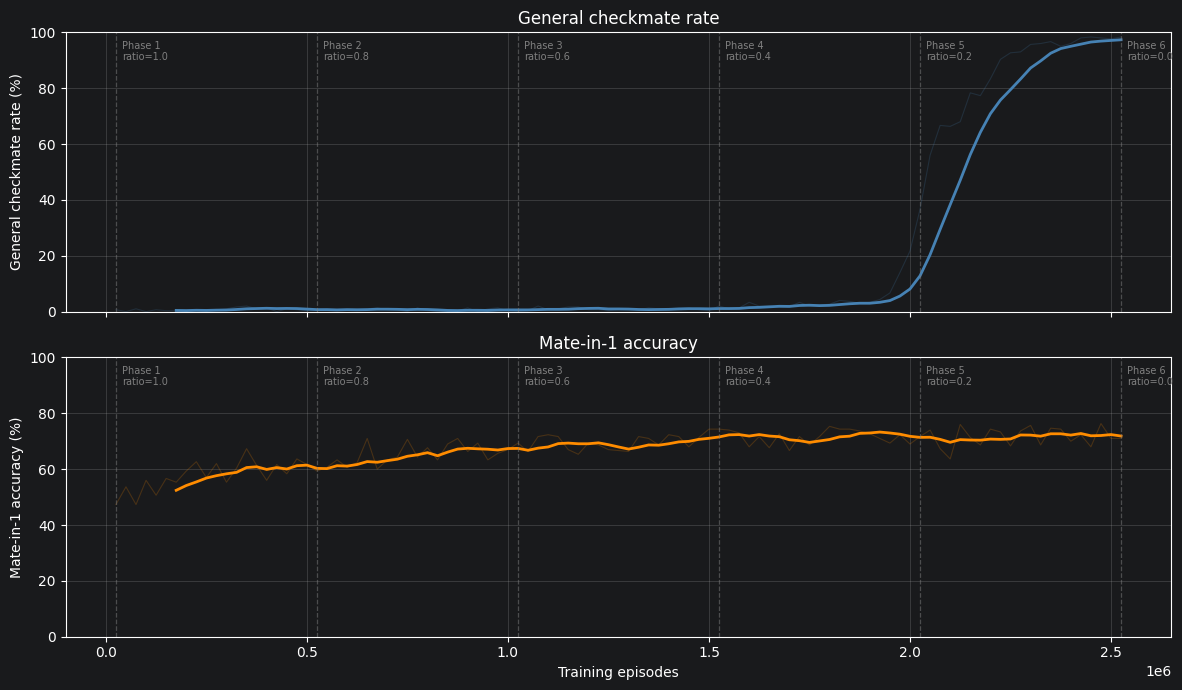

 Phase   ratio   end gen%   end m1%
     1.0        1.0      60.8
     0.8        0.6      66.7
     0.6        0.9      70.2
     0.4        6.6      72.4
     0.2       96.4      72.5
     0.0       98.3      71.0


In [593]:
_path = os.path.join(os.path.dirname(os.path.abspath("__file__")), "ppo_full_history.json")
with open(_path) as _f:
    _hist = json.load(_f)

episodes = [h["episode"]              for h in _hist]
gen_rate = [h["checkmate_rate"] * 100 for h in _hist]
m1_rate  = [h["mate_in_one"]    * 100 for h in _hist]

_boundaries = {}
for h in _hist:
    if h["ratio"] not in _boundaries:
        _boundaries[h["ratio"]] = h["episode"]

def _smooth(y, w=7):
    return np.convolve(y, np.ones(w)/w, mode="valid")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax1.plot(episodes, gen_rate, color="steelblue", alpha=0.2, linewidth=0.8)
ax1.plot(episodes[6:], _smooth(gen_rate), color="steelblue", linewidth=2)
ax1.set_ylabel("General checkmate rate (%)")
ax1.set_title("General checkmate rate")
ax1.set_ylim(0, 100)
ax1.grid(True, alpha=0.3)

ax2.plot(episodes, m1_rate, color="darkorange", alpha=0.2, linewidth=0.8)
ax2.plot(episodes[6:], _smooth(m1_rate), color="darkorange", linewidth=2)
ax2.set_ylabel("Mate-in-1 accuracy (%)")
ax2.set_title("Mate-in-1 accuracy")
ax2.set_ylim(0, 100)
ax2.set_xlabel("Training episodes")
ax2.grid(True, alpha=0.3)

# Phase boundaries
_ratio_labels = {1.0: "Phase 1\nratio=1.0", 0.8: "Phase 2\nratio=0.8",
                 0.6: "Phase 3\nratio=0.6", 0.4: "Phase 4\nratio=0.4",
                 0.2: "Phase 5\nratio=0.2", 0.0: "Phase 6\nratio=0.0\n"}
for ratio, ep in sorted(_boundaries.items(), key=lambda x: x[1]):
    for ax in (ax1, ax2):
        ax.axvline(ep, color="gray", linewidth=0.9, linestyle="--", alpha=0.5)
        ax.text(ep + 15_000, ax.get_ylim()[1]*0.97, _ratio_labels.get(ratio, ""),
                fontsize=7, color="gray", va="top")

plt.tight_layout()
plt.show()

# Per-phase summary
print(f"{'Phase':>6}  {'ratio':>6}  {'end gen%':>9}  {'end m1%':>8}")
for ratio, grp in _gb(_hist, key=lambda h: h['ratio']):
    pts = list(grp)
    last = pts[-min(10, len(pts)):]
    gen = sum(h['checkmate_rate'] for h in last)/len(last)*100
    m1  = sum(h['mate_in_one']    for h in last)/len(last)*100
    print(f"  {ratio:>6.1f}  {gen:>9.1f}  {m1:>8.1f}")

## 4. Reward Shaping

### Step penalty
The step penalty stops the agent from stalling. Too small (−0.001) and a 200-step episode only costs −0.2 total, no urgency. Too large (−0.15) and a 50-move game costs −7.5, which can overwhelm the +10 checkmate reward.
−0.15 works: a 15-move checkmate costs −2.25, a 50-move draw costs −7.5. Clear difference.

### Queen-hang penalty
Before the −5.0 penalty, the agent regularly moved the queen to a square the black king could immediately take. It hadn't learned the queen is irreplaceable.
After the penalty, this failure mode basically disappeared within a few thousand episodes.

### Missed-mate penalty
Without the penalty, the agent sometimes skipped an available checkmate and made a different move instead. The −3.0 penalty for missing a forced mate fixed this directly.

## 5. Opponent Difficulty

The opponent is the Black King, controlled by a heuristic.

- Random: Black King picks a random legal square each move.
- Centrum: Black King always moves toward the board center; more escape squares, harder to trap.
- Neural: A second PPO network trained to survive as long as possible (see Section 8).

The same agent (kqk_ppo_v2_stage_4) evaluated greedy vs each opponent type (n=1000).

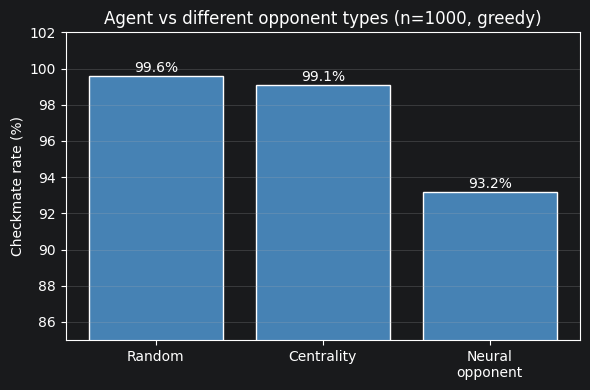

Random:  99.6%, occasionally escapes by chance
Centrum: 99.1%, consistent centrality is harder to corner
Neural:  93.2%, adversarially trained to evade, genuinely harder


In [612]:
_path = os.path.join(os.path.dirname(os.path.abspath("__file__")), "opponent_eval.json")
with open(_path) as _f:
    _opp = json.load(_f)

_labels = ["Random", "Centrality", "Neural\nopponent"]
_rates  = [_opp["random"]["checkmate_rate"]*100,
           _opp["centrum"]["checkmate_rate"]*100,
           _opp["neural"]["checkmate_rate"]*100]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(_labels, _rates, color="steelblue", edgecolor="white")
ax.set_ylabel("Checkmate rate (%)")
ax.set_title("Agent vs different opponent types (n=1000, greedy)")
ax.set_ylim(85, 102)
for i, r in enumerate(_rates):
    ax.text(i, r + 0.2, f"{r:.1f}%", ha="center", fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Random:  {_rates[0]:.1f}%, occasionally escapes by chance")
print(f"Centrum: {_rates[1]:.1f}%, consistent centrality is harder to corner")
print(f"Neural:  {_rates[2]:.1f}%, adversarially trained to evade, genuinely harder")

## 6. Curriculum Ratio

`curriculum_ratio` controls how training episodes are split:
- ratio=1.0 — 100% mate-in-1 positions
- ratio=0.5 — 50% mate-in-1, 50% random start positions
- ratio=0.0 — 100% random start positions

Data below shows where each metric stood at the end of each phase in the 3M-episode training run.

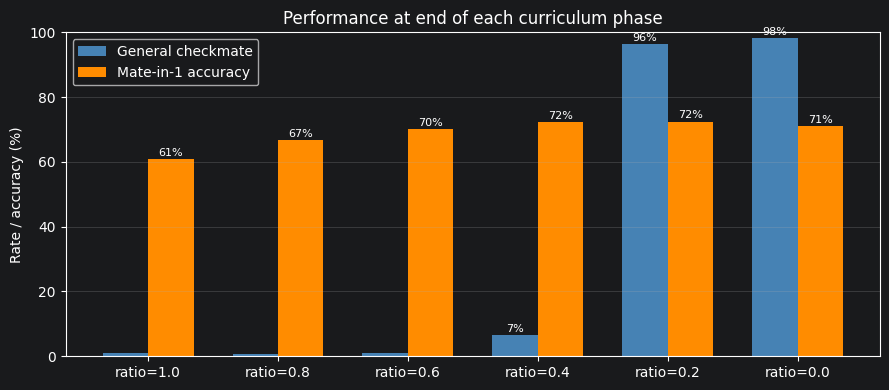

Key observations:
  ratio=1.0 end: general=1.0%  mate-in-1=60.8%
  ratio=0.0 end: general=98.3%  mate-in-1=71.0%
  General checkmate only takes off when ratio=0.0 forces fully random positions.
  But starting with a ratio of 0.0 ends in it never finding checkmate.


In [607]:
_path = os.path.join(os.path.dirname(os.path.abspath("__file__")), "ppo_full_history.json")
with open(_path) as _f:
    _hist = json.load(_f)

_phase_summary = []
for ratio, grp in _gb(_hist, key=lambda h: h['ratio']):
    pts  = list(grp)
    last = pts[-min(10, len(pts)):]
    gen  = sum(h['checkmate_rate'] for h in last) / len(last) * 100
    m1   = sum(h['mate_in_one']    for h in last) / len(last) * 100
    _phase_summary.append((ratio, gen, m1))

ratios   = [p[0] for p in _phase_summary]
gen_vals = [p[1] for p in _phase_summary]
m1_vals  = [p[2] for p in _phase_summary]

x = np.arange(len(ratios))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w/2, gen_vals, w, label="General checkmate", color="steelblue")
ax.bar(x + w/2, m1_vals,  w, label="Mate-in-1 accuracy", color="darkorange")
ax.set_xticks(x)
ax.set_xticklabels([f"ratio={r:.1f}" for r in ratios])
ax.set_ylabel("Rate / accuracy (%)")
ax.set_title("Performance at end of each curriculum phase")
ax.set_ylim(0, 100)
ax.legend()
ax.grid(axis="y", alpha=0.3)
for i, (g, m) in enumerate(zip(gen_vals, m1_vals)):
    if g > 2: ax.text(i-w/2, g+1, f"{g:.0f}%", ha="center", fontsize=8)
    if m > 2: ax.text(i+w/2, m+1, f"{m:.0f}%", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

print("Key observations:")
print(f"  ratio=1.0 end: general={gen_vals[0]:.1f}%  mate-in-1={m1_vals[0]:.1f}%")
print(f"  ratio=0.0 end: general={gen_vals[-1]:.1f}%  mate-in-1={m1_vals[-1]:.1f}%")
print(f"  General checkmate only takes off when ratio=0.0 forces fully random positions.\n"
      f"  But starting with a ratio of 0.0 ends in it never finding checkmate.")

## 7. Learning Rate

Three PPO runs from scratch, 100k episodes each, curriculum_ratio=1.0 (mate-in-1 positions).
Metric: mate-in-1 accuracy evaluated greedily every 10k episodes.

- lr = 1e-2: Doesn't improve much.
- lr = 1e-3: Gradual improvement, reaches around 28% by 100k episodes.
- lr = 1e-4: Best of the three, steady climb to 34% and still rising at 100k episodes.

Why does 1e-4 win here?
Chess has a large action space (4096 possible moves) and many things to improve simultaneously; piece placement, king trapping, avoiding queen loss. Large updates overshoot: a gradient step that improves one aspect of play can undo progress on another. Smaller steps let the policy refine multiple objectives at once without oscillating.

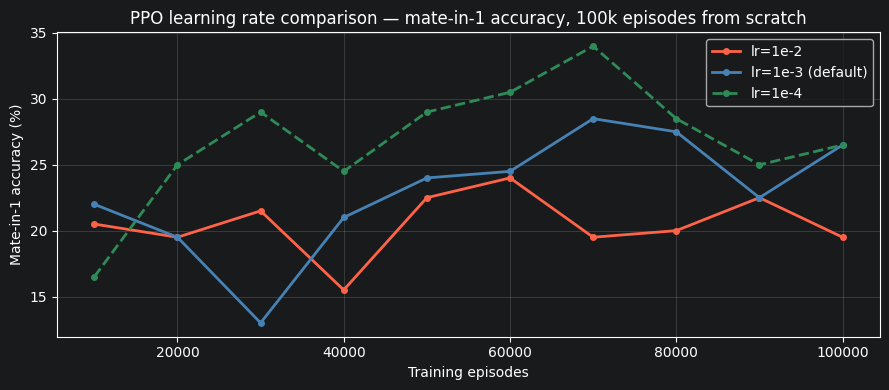

In [596]:
_path = os.path.join(os.path.dirname(os.path.abspath("__file__")), "lr_comparison_ppo.json")
with open(_path) as _f:
    _lr_data = json.load(_f)

fig, ax = plt.subplots(figsize=(9, 4))
_styles = {
    "0.01":   ("lr=1e-2",           "tomato",    "-"),
    "0.001":  ("lr=1e-3 (default)", "steelblue", "-"),
    "0.0001": ("lr=1e-4",           "seagreen",  "--"),
}
for key, (label, color, ls) in _styles.items():
    if key not in _lr_data: continue
    y = [v*100 for v in _lr_data[key]]
    x = [10_000 * (i+1) for i in range(len(y))]
    ax.plot(x, y, label=label, color=color, linestyle=ls, linewidth=2, marker="o", markersize=4)

ax.set_xlabel("Training episodes")
ax.set_ylabel("Mate-in-1 accuracy (%)")
ax.set_title("PPO learning rate comparison — mate-in-1 accuracy, 100k episodes from scratch")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Self-Play

After v5 reached ~99% against the centrality opponent, I trained it against a learned neural opponent.

A PPOOpponent (black) was trained separately to survive as long as possible against the white agent. Then white was trained against frozen weights of that opponent.

Freezing is important: if both networks update simultaneously, white chases a moving target and training destabilizes. The approach is: train white for N episodes → snapshot opponent → repeat.

The result: ~93% against the neural opponent vs ~99% against centrality. The neural opponent learned to delay and exploit weaknesses that the deterministic central movement opponent never exposes.

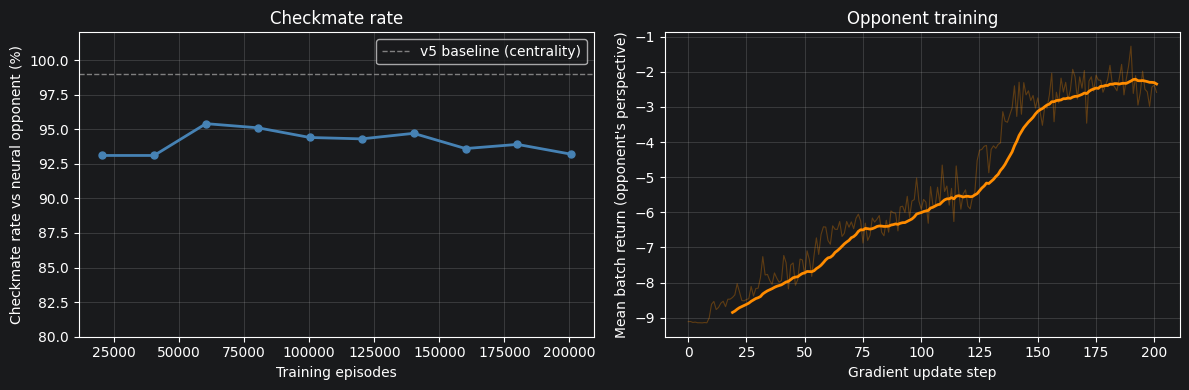

White agent: 93.1% → 93.2% checkmate vs neural opponent
Opponent reward: -9.11 → -2.59 (higher = surviving longer)


In [610]:
_hist_path = os.path.join(AGENTS_DIR, "v7", "train_history.json")
_opp_path  = os.path.join(AGENTS_DIR, "v7", "opponent_train_history.json")

with open(_hist_path) as _f:  _hist = json.load(_f)
with open(_opp_path)  as _f:  _opp  = json.load(_f)

eval_eps  = [e["episode"]        for e in _hist["eval_history"]]
eval_rate = [e["checkmate_rate"] * 100 for e in _hist["eval_history"]]
opp_rew   = _opp["train_rewards"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(eval_eps, eval_rate, "o-", color="steelblue", linewidth=2, markersize=5)
ax1.axhline(99, color="gray", linestyle="--", linewidth=1, label="v5 baseline (centrality)")
ax1.set_xlabel("Training episodes")
ax1.set_ylabel("Checkmate rate vs neural opponent (%)")
ax1.set_title("Checkmate rate")
ax1.set_ylim(80, 102)
ax1.legend()
ax1.grid(True, alpha=0.3)

_w = 20
_sm = np.convolve(opp_rew, np.ones(_w)/_w, mode="valid")
ax2.plot(opp_rew, alpha=0.3, color="darkorange", linewidth=0.8)
ax2.plot(range(_w-1, len(opp_rew)), _sm, color="darkorange", linewidth=2)
ax2.set_xlabel("Gradient update step")
ax2.set_ylabel("Mean batch return (opponent's perspective)")
ax2.set_title("Opponent training")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"White agent: {eval_rate[0]:.1f}% → {eval_rate[-1]:.1f}% checkmate vs neural opponent")
print(f"Opponent reward: {opp_rew[0]:.2f} → {opp_rew[-1]:.2f} (higher = surviving longer)")

## 9. Final Agent Evaluation

The best agent (kqk_ppo_v2_stage_4) evaluated on 1000 random KQK positions against the centrality opponent (greedy play).

In [598]:
MODEL_PATH = os.path.join(os.path.dirname(os.path.abspath("__file__")),
                          "..", "notebooks", "models", "kqk_ppo_v2_stage_4.pt")

agent = PPOAgent(curriculum_ratio=0.0)
try:
    agent.net.load_state_dict(torch.load(MODEL_PATH, map_location="cpu"))
    agent.net.eval()
    print(f"Loaded: {MODEL_PATH}")
    model_loaded = True
except FileNotFoundError:
    print(f"Model not found: {MODEL_PATH}")
    model_loaded = False

Using device: cuda
Loaded: /home/anass/School/chessMate/report/../notebooks/models/kqk_ppo_v2_stage_4.pt



--- Eval (1000 eps, movement=centrum) ---
  checkmate                     : 994
  missed_mate                   : 4
  queen_hang                    : 2
  mean_steps                    : 9.2
  checkmate_rate                : 99.4%


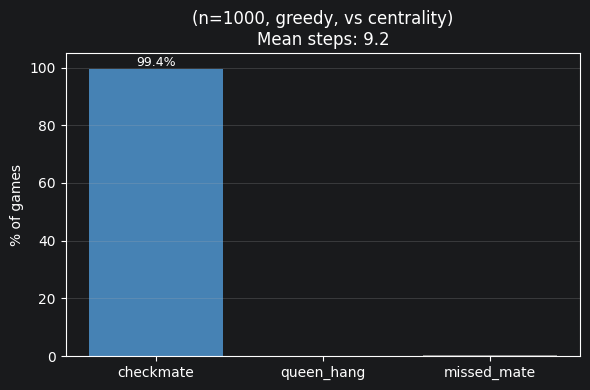

In [601]:
if model_loaded:
    import importlib, agents.v6.ppo_agent as _m
    importlib.reload(_m)
    results = agent.evaluate(n_episodes=1000, movement="centrum")

    if results is None:
        print("evaluate() returned None — please restart the kernel and re-run.")
    else:
        outcome_counts = {k: v for k, v in results.items()
                          if k not in ("mean_steps", "checkmate_rate")}
        total = sum(outcome_counts.values())
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.bar(outcome_counts.keys(),
               [v/total*100 for v in outcome_counts.values()],
               color=["steelblue" if k == "checkmate" else "gray" for k in outcome_counts])
        ax.set_ylabel("% of games")
        ax.set_title(f"(n=1000, greedy, vs centrality)\n"
                     f"Mean steps: {results['mean_steps']:.1f}")
        ax.set_ylim(0, 105)
        for i, (k, v) in enumerate(outcome_counts.items()):
            pct = v/total*100
            if pct > 0.5:
                ax.text(i, pct+1, f"{pct:.1f}%", ha="center", fontsize=9)
        ax.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        plt.show()

In [600]:
if model_loaded:
    agent.animate_game(greedy=True, movement="centrum")